# Table of Contents

1. [Load Data](#load-data)
2. [Data Cleaning and Feature engineering](#data-cleaning-and-feature-engineering)
3. [Dimentionality Reduction](#dimentionality-reduction)
4. [Silhouette and Elbow Score for k selection](##silhouette-and-Elbow-Score-for-k-selection)
5. [Imported Cluster Labels](#imported-cluster-labels)
6. [Result Analysis & Visualizations](#result-analysis--visualizations)

## Note, Please follow this order to run the files:
### 1. Run 1. to 4. first. 
### 2. Then run the Rmarkdown file. (Version_A_Selective_Inference.Rmd)
### 3. Run 5. and 6. for visualization and final labels.

## Load Data

In [81]:
import pandas as pd
from pathlib import Path

csv_path = "../Clustering/clustering_Cleaned.csv"
df_full = pd.read_csv(csv_path)  # Keep full dataframe for later merging

# Filter for individual only
df = df_full[df_full['kyc_type'].str.lower() == 'individual'].copy()
print(f"Full dataset: {len(df_full)} rows")
print(f"Filtered to individual customers only: {len(df)} rows")

df.head()
df.isna().sum()

Full dataset: 61410 rows
Filtered to individual customers only: 53099 rows


C:\Users\houju\AppData\Local\Temp\ipykernel_65932\128460308.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(csv_path)  # Keep full dataframe for later merging


customer_id                                 0
kyc_type                                    0
province                                    0
city                                        0
industry_code                           53099
occupation_code                            87
sales_cents                             53099
account_age                              4025
birth_business_age                       3526
total_transaction_count                     0
transaction_count_ABM                       0
transaction_count_Card                      0
transaction_count_Cheque                    0
transaction_count_EFT                       0
transaction_count_EMT                       0
transaction_count_Western Union             0
transaction_count_Wire                      0
debit_transaction_count                   337
debit_transaction_amount                  337
credit_transaction_count                 1655
credit_transaction_amount                1655
average_debit_transaction_amount  

## Data Cleaning and Feature engineering

In [82]:
# Keep occupation_code for individual, drop industry_code
import numpy as np

# Drop redundant or unneeded columns
df = df.drop(columns=["industry_code", 'Debit_Amount_Total', 'Credit_Amount_Total', 'abm_transaction_count'])

# Fill NA values in occupation_code with mode
if 'occupation_code' in df.columns:
    mode_value = df['occupation_code'].mode()
    if len(mode_value) > 0:
        df['occupation_code'] = df['occupation_code'].fillna(mode_value[0])
        print(f"Filled NA values in 'occupation_code' with mode: {mode_value[0]}")
    else:
        print("Warning: Could not find mode for 'occupation_code' (all values may be NA)")

# Convert occupation_code to categorical dtype (FAMD)
df["occupation_code"] = df["occupation_code"].astype("category")

print("occupation_code nunique:", df["occupation_code"].nunique())
print(df["occupation_code"].value_counts().head(10))

Filled NA values in 'occupation_code' with mode: OTHER
occupation_code nunique: 102
occupation_code
OTHER            10770
RETIRED          10243
STUDENT           6149
UNEMPLOYED        4952
SELF_EMPLOYED     4492
10019             1504
60010              709
14100              687
313                623
73300              618
Name: count, dtype: int64


In [83]:
# Replace occupation_code values that appear less than 300 times with "OTHER"
if 'occupation_code' in df.columns:
    # Count frequency of each occupation_code
    occupation_code_counts = df['occupation_code'].value_counts()
    
    # Find occupation_code values that appear less than 300 times (excluding NaN)
    rare_occupation_codes = occupation_code_counts[occupation_code_counts < 300].index.tolist()
    
    print(f"Found {len(rare_occupation_codes)} occupation_code values appearing less than 300 times")
    
    # Create mask for rows with rare occupation_code values
    rare_mask = df['occupation_code'].isin(rare_occupation_codes)
    print(f"Total rows to be changed: {rare_mask.sum()}")
    
    # Replace rare occupation_code values with "OTHER"
    df.loc[rare_mask, 'occupation_code'] = 'OTHER'
    
    # Drop unused category levels. Otherwise value_counts() can list 0-count levels and
    if hasattr(df['occupation_code'].dtype, 'categories'):
        df['occupation_code'] = df['occupation_code'].cat.remove_unused_categories()
    else:
        df['occupation_code'] = df['occupation_code'].astype('category')
    
    # Show updated distribution
    print(f"\nUpdated occupation_code distribution:")
    print(df['occupation_code'].value_counts().head(20))
else:
    print("Column 'occupation_code' not found in dataframe")



Found 87 occupation_code values appearing less than 300 times
Total rows to be changed: 10079

Updated occupation_code distribution:
occupation_code
OTHER            20849
RETIRED          10243
STUDENT           6149
UNEMPLOYED        4952
SELF_EMPLOYED     4492
10019             1504
60010              709
14100              687
313                623
73300              618
65100              601
95109              516
11100              485
9201               339
11102              332
Name: count, dtype: int64


In [84]:
# account_age and birth_business_age: fill nulls with median
df['account_age'] = df['account_age'].fillna(df['account_age'].median())
df['birth_business_age'] = df['birth_business_age'].fillna(df['birth_business_age'].median())

# Fill debit and credit nulls to 0
debit_credit_cols = [
    'debit_transaction_count',
    'debit_transaction_amount',
    'average_debit_transaction_amount',
    'credit_transaction_count',
    'credit_transaction_amount',
    'average_credit_transaction_amount'
]

for col in debit_credit_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 4. Fill nulls in columns with prefix 'card_' or 'abm_' to 0
card_abm_cols = [col for col in df.columns if (col.startswith('card_') or col.startswith('abm_')) and col != 'abm_cash_to_non_cash_ratio']
for col in card_abm_cols:
    if col == 'card_top_mcc':
        df[col] = df[col].fillna('N/A')
    elif col == 'card_second_mcc':
        df[col] = df[col].fillna('N/A')
    elif col == 'card_ecommerce_to_nonecommerce_ratio':
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(0)

In [85]:
# Replace MCC codes in card_top_mcc that appear less than 300 times with "other"
if 'card_top_mcc' in df.columns:
    mcc_counts = df['card_top_mcc'].value_counts()
    
    # Find MCC codes that appear less than 300 times (excluding N/A and null)
    rare_mccs = mcc_counts[mcc_counts < 300].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_mccs:
        rare_mccs.remove('N/A')
    
    print(f"Found {len(rare_mccs)} MCC codes appearing less than 300 times")
    print(f"Total rows to be changed: {df['card_top_mcc'].isin(rare_mccs).sum()}")
    
    # Replace rare MCC codes with "other"
    df.loc[df['card_top_mcc'].isin(rare_mccs), 'card_top_mcc'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated card_top_mcc distribution:")
    print(df['card_top_mcc'].value_counts().head(10))

Found 71 MCC codes appearing less than 300 times
Total rows to be changed: 1852

Updated card_top_mcc distribution:
card_top_mcc
5814     22206
5411     11382
N/A       7950
0         2329
other     2171
5310      1677
5812      1412
5541      1033
4816       609
4121       506
Name: count, dtype: int64


In [86]:
# Replace cities that appear less than 300 times with "other"
if 'city' in df.columns:
    city_counts = df['city'].value_counts()
    
    # Find cities that appear less than 300 times (excluding N/A and null)
    rare_cities = city_counts[city_counts < 300].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_cities:
        rare_cities.remove('N/A')
    
    print(f"Found {len(rare_cities)} cities appearing less than 100 times")
    print(f"Total rows to be changed: {df['city'].isin(rare_cities).sum()}")
    
    # Replace rare cities with "other"
    df.loc[df['city'].isin(rare_cities), 'city'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated city distribution:")
    print(df['city'].value_counts().head(10))

Found 118 cities appearing less than 100 times
Total rows to be changed: 14201

Updated city distribution:
city
other          31827
TORONTO         3230
BRAMPTON        2046
CALGARY         1773
EDMONTON        1691
WINNIPEG        1291
SCARBOROUGH     1260
MISSISSAUGA     1200
SURREY          1094
VANCOUVER       1028
Name: count, dtype: int64


In [87]:
# Cheque, western union and wire are turned to be binary indicators due to high skewness
# Cheque binary indicators (1 if count non-zero, else 0)
_cheque_col = "transaction_count_Cheque"
if _cheque_col in df.columns:
    df["cheque_user"] = (df[_cheque_col].fillna(0) != 0).astype(int)
    df = df.drop(columns=[_cheque_col])
    print(f"Created 'cheque_user' from '{_cheque_col}' (1 if non-zero) and dropped count column")
else:
    print(f"Warning: '{_cheque_col}' not found; 'cheque_user' not created")

# Western Union binary indicator (1 if count non-zero, else 0)
_western_union_col = "transaction_count_Western Union"
if _western_union_col in df.columns:
    df["western_union_user"] = (df[_western_union_col].fillna(0) != 0).astype(int)
    df = df.drop(columns=[_western_union_col])
    print(f"Created 'western_union_user' from '{_western_union_col}' (1 if non-zero) and dropped count column")
else:
    print(f"Warning: '{_western_union_col}' not found; 'western_union_user' not created")

# Wire binary indicator (1 if count non-zero, else 0)
_wire_col = "transaction_count_Wire"
if _wire_col in df.columns:
    df["wire_user"] = (df[_wire_col].fillna(0) != 0).astype(int)
    df = df.drop(columns=[_wire_col])
    print(f"Created 'wire_user' from '{_wire_col}' (1 if non-zero) and dropped count column")
else:
    print(f"Warning: '{_wire_col}' not found; 'wire_user' not created")

#Remove customer_id, card_second_mcc, and sales_cents for individual
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])
if 'card_second_mcc' in df.columns:
    df = df.drop(columns=['card_second_mcc'])
if 'sales_cents' in df.columns:
    df = df.drop(columns=['sales_cents'])
# Drop ABM non-cash count column
if 'abm_non_cash_count' in df.columns:
    df = df.drop(columns=['abm_non_cash_count'])
# Drop abm_cash_to_non_cash_ratio column
if 'abm_cash_to_non_cash_ratio' in df.columns:
    df = df.drop(columns=['abm_cash_to_non_cash_ratio'])
    print("Dropped 'abm_cash_to_non_cash_ratio' column")
if "card_ecommerce_to_nonecommerce_ratio" in df.columns:
    df=df.drop(columns=['card_ecommerce_to_nonecommerce_ratio'])

# Rename Averagetime_between_alltransaction to Averagetime_between_transaction_day
if 'Averagetime_between_alltransaction' in df.columns:
    df = df.rename(columns={'Averagetime_between_alltransaction': 'Averagetime_between_transaction_day'})
    print("Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'")

# Fill Averagetime_between_transaction_day with median (not 0)
if 'Averagetime_between_transaction_day' in df.columns:
    median_value = df['Averagetime_between_transaction_day'].median()
    df['Averagetime_between_transaction_day'] = df['Averagetime_between_transaction_day'].fillna(median_value)
    print(f"Filled null values in 'Averagetime_between_transaction_day' with median: {median_value:.4f}")
else:
    print("Warning: Column 'Averagetime_between_transaction_day' not found in dataframe")

# Fill std_time_between_transactions with median
if 'std_time_between_transactions' in df.columns:
    median_value = df['std_time_between_transactions'].median()
    df['std_time_between_transactions'] = df['std_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'std_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'std_time_between_transactions' not found in dataframe")

# Fill median_time_between_transactions with median
if 'median_time_between_transactions' in df.columns:
    median_value = df['median_time_between_transactions'].median()
    df['median_time_between_transactions'] = df['median_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'median_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'median_time_between_transactions' not found in dataframe")

# pct_transactions_top10_busiest_days does not have NA values, so no filling needed
if 'pct_transactions_top10_busiest_days' in df.columns:
    na_count = df['pct_transactions_top10_busiest_days'].isna().sum()
    print(f"Column 'pct_transactions_top10_busiest_days' has {na_count} NA values (no filling needed)")
else:
    print("Warning: Column 'pct_transactions_top10_busiest_days' not found in dataframe")


# Drop additional columns before FAMD
df = df.drop(columns=['card_transaction_count',"total_transaction_count", "transaction_count_Card"])

Created 'cheque_user' from 'transaction_count_Cheque' (1 if non-zero) and dropped count column
Created 'western_union_user' from 'transaction_count_Western Union' (1 if non-zero) and dropped count column
Created 'wire_user' from 'transaction_count_Wire' (1 if non-zero) and dropped count column
Dropped 'abm_cash_to_non_cash_ratio' column
Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'
Filled null values in 'Averagetime_between_transaction_day' with median: 1.3292
Filled null values in 'std_time_between_transactions' with median: 1.3705
Filled null values in 'median_time_between_transactions' with median: 0.8781
Column 'pct_transactions_top10_busiest_days' has 0 NA values (no filling needed)


In [88]:
# Count number of categories for each categorical column after small category removal
print("CATEGORICAL COLUMNS - NUMBER OF CATEGORIES")
print("=" * 80)

# Identify categorical columns (object dtype and category dtype)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove kyc_type since it's constant
if 'kyc_type' in categorical_cols:
    categorical_cols.remove('kyc_type')
    df = df.drop(columns=['kyc_type'])

category_summary = []

for col in categorical_cols:
    n_unique = df[col].nunique()
    n_null = df[col].isna().sum()
    category_summary.append({
        'Column': col,
        'Number of Categories': n_unique,
        'Null Count': n_null,
        'Dtype': str(df[col].dtype)
    })

category_df = pd.DataFrame(category_summary)
category_df = category_df.sort_values('Number of Categories', ascending=False)

print(f"\nFound {len(categorical_cols)} categorical columns:\n")
print(category_df.to_string(index=False))

print(f"Total categorical columns: {len(categorical_cols)}")
print(f"Min categories: {category_df['Number of Categories'].min()} ({category_df.loc[category_df['Number of Categories'].idxmin(), 'Column']})")

CATEGORICAL COLUMNS - NUMBER OF CATEGORIES

Found 4 categorical columns:

         Column  Number of Categories  Null Count    Dtype
           city                    24           0   object
occupation_code                    15           0 category
   card_top_mcc                    15           0   object
       province                    12           0   object
Total categorical columns: 4
Min categories: 12 (province)


In [89]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical columns (will be preserved): {categorical_cols}")

# Convert all non-categorical columns to float64
non_categorical_cols = [col for col in df.columns if col not in categorical_cols]

conversion_summary = []
for col in non_categorical_cols:
    old_dtype = str(df[col].dtype)
    df[col] = df[col].astype('float64')
    new_dtype = str(df[col].dtype)
    conversion_summary.append({
        'Column': col,
        'Old Dtype': old_dtype,
        'New Dtype': new_dtype
    })

print(f"Converted {len(non_categorical_cols)} columns to float64")

# Show dtype summary
print("FINAL DATA TYPE SUMMARY:")
print(f"Total columns: {len(df.columns)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Float64 columns: {len(non_categorical_cols)}")


Categorical columns (will be preserved): ['province', 'city', 'occupation_code', 'card_top_mcc']
Converted 26 columns to float64
FINAL DATA TYPE SUMMARY:
Total columns: 30
Categorical columns: 4
Float64 columns: 26


## Dimentionality Reduction

In [90]:
import prince

df_famd = df.copy()
# Add customer_id back before saving to VersionB_BeforeFAMD.csv (preserving order, no sorting)
if 'customer_id' not in df_famd.columns:
    original_csv_path = "../Clustering/clustering_Cleaned.csv"
    df_original = pd.read_csv(original_csv_path)
    df_original = df_original[df_original['kyc_type'].str.lower() == 'individual'].copy()
    print(f"Full dataset: {len(df_original)} rows")
    print(f"Filtered to individual customers only: {len(df_original)} rows")
    # Use index alignment to preserve order
    if len(df_original) == len(df_famd):
        df_original_reset = df_original.reset_index(drop=True)
        df_famd_reset = df_famd.reset_index(drop=True)
        df_famd['customer_id'] = df_original_reset['customer_id'].values
        print("customer_id restored from original dataset (order preserved)")
    else:
        raise ValueError(f"Row count mismatch! Original: {len(df_original)}, Current: {len(df_famd)}")

# Reorder columns to put customer_id first (preserving row order)
if 'customer_id' in df_famd.columns:
    cols = ['customer_id'] + [col for col in df_famd.columns if col != 'customer_id']
    df_famd = df_famd[cols]
before_famd = "../Clustering/VersionA_Individual_BeforeFAMD.csv"
df_famd.to_csv(before_famd, index=False)
print(f"Saved to {before_famd}")
# Remove customer_id after saving (preserving row order)
if 'customer_id' in df_famd.columns:
    df_famd = df_famd.drop(columns=['customer_id'])
    print("customer_id removed after saving (order preserved)")

famd = prince.FAMD(
    n_components=6,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42,
    engine="sklearn",
    handle_unknown="error"
)

famd = famd.fit(df_famd)

famd.eigenvalues_summary

C:\Users\houju\AppData\Local\Temp\ipykernel_65932\3581822832.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv(original_csv_path)


Full dataset: 53099 rows
Filtered to individual customers only: 53099 rows
customer_id restored from original dataset (order preserved)
Saved to ../Clustering/VersionA_Individual_BeforeFAMD.csv
customer_id removed after saving (order preserved)


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,7.878,5.25%,5.25%
1,3.847,2.56%,7.82%
2,3.691,2.46%,10.28%
3,3.513,2.34%,12.62%
4,3.462,2.31%,14.93%
5,3.385,2.26%,17.18%


In [91]:
famd.column_contributions_.style.format('{:.2%}')

component,0,1,2,3,4,5
variable,,,,,,
account_age,0.01%,0.71%,2.12%,0.03%,4.73%,0.16%
birth_business_age,0.18%,0.94%,2.54%,0.09%,5.75%,0.15%
transaction_count_ABM,0.66%,0.00%,0.08%,0.00%,0.36%,0.04%
transaction_count_EFT,0.16%,0.00%,0.04%,0.01%,0.25%,0.00%
transaction_count_EMT,0.20%,0.02%,0.04%,0.05%,0.01%,0.04%
debit_transaction_count,9.73%,0.02%,0.01%,0.00%,0.00%,0.04%
debit_transaction_amount,0.53%,0.00%,0.00%,0.01%,0.01%,0.02%
credit_transaction_count,0.86%,0.00%,0.00%,0.04%,0.10%,0.03%
credit_transaction_amount,0.01%,0.00%,0.01%,0.00%,0.04%,0.01%


In [92]:
# Row coordinates = FAMD component scores for each row
X_famd = famd.row_coordinates(df_famd)

print("FAMD scores shape:", X_famd.shape)
before_famd = "../Clustering/VersionA_Individual_AfterFAMD.csv"
X_famd.to_csv(before_famd, index=False)
X9 = X_famd.iloc[:, :8].to_numpy()

FAMD scores shape: (53099, 6)


## Silhouette and Elbow Score for k selection

k=4 silhouette=0.3242
k=5 silhouette=0.3547
k=6 silhouette=0.3700
k=7 silhouette=0.3377
k=8 silhouette=0.3155

KMeans results:
   k  silhouette
0  4    0.324239
1  5    0.354700
2  6    0.370050
3  7    0.337660
4  8    0.315459


,k,inertia,silhouette
0,4,787932.62500,0.324239
1,5,598308.75000,0.354700
2,6,458205.62500,0.370050
3,7,384629.90625,0.337660
4,8,328534.21875,0.315459


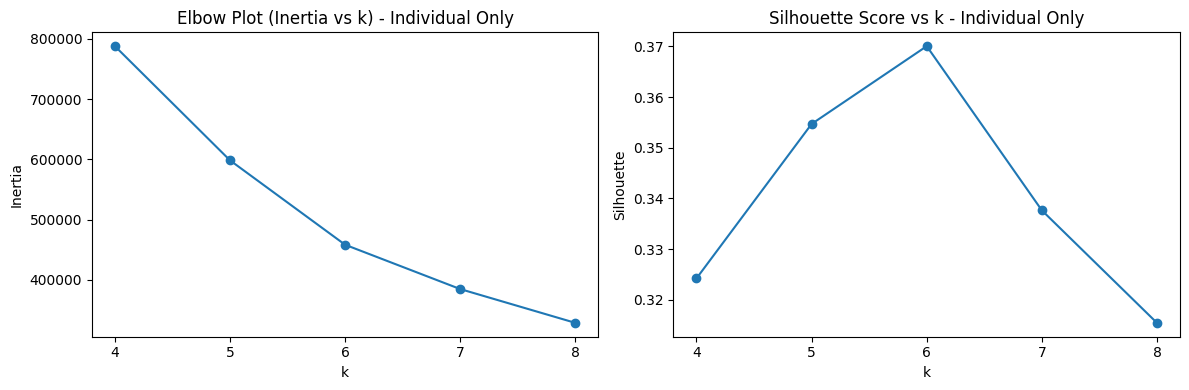

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Prepare dataset for clustering (FAMD row coordinates)
X_32 = np.asarray(X9, dtype=np.float32, order="C")
X = X_32

k_list = [4, 5, 6, 7, 8]
sil = []

for k in k_list:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X)
    s = silhouette_score(X, labels)
    sil.append(s)
    print(f"k={k} silhouette={s:.4f}")

kmeans_results = pd.DataFrame({"k": k_list, "silhouette": sil})
print("\nKMeans results:")
print(kmeans_results)

# Get silhouette series from existing results
if "kmeans_results" in globals():
    ks = kmeans_results["k"].tolist()
    sil_scores = kmeans_results["silhouette"].tolist()
else:
    ks = k_list
    sil_scores = sil

ks = [int(k) for k in ks]

# Compute inertia for elbow
inertia = []
for k in ks:
    km = KMeans(n_clusters=int(k), n_init="auto", random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

# combine into one table
eval_df = pd.DataFrame({"k": ks, "inertia": inertia, "silhouette": sil_scores})
display(eval_df)

# Plot: Elbow + Silhouette (two panels)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(ks, inertia, marker="o")
ax[0].set_title("Elbow Plot (Inertia vs k) - Individual Only")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")
ax[0].set_xticks(ks)

ax[1].plot(ks, sil_scores, marker="o")
ax[1].set_title("Silhouette Score vs k - Individual Only")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
ax[1].set_xticks(ks)

plt.tight_layout()
plt.show()

## Imported Cluster Labels

Cluster assignments come from `individual_kmeans_estimation_labels` from Kmeans clustering in Rmarkdown. Please follow the following operations:
1. Run the code above. The elbow and silhouette score assists k selection.
2. Run the Rmarkdown with the created csv from above code.
3. Run the code below for visualization.

In [94]:
KMEANS_LABELS_CSV = "../Clustering/individual_kmeans_estimation_labels.csv"


def _load_kmeans_labels(path):
    df_lab = pd.read_csv(path, sep=None, engine="python")
    df_lab.columns = df_lab.columns.str.strip()
    for col in ("customer_id", "cluster_raw", "cluster_num"):
        if col not in df_lab.columns:
            raise ValueError(f"Expected column {col!r} in {path}, got {list(df_lab.columns)}")
    return df_lab

kmeans_labels_df = _load_kmeans_labels(KMEANS_LABELS_CSV)
individual_mask = df_full["kyc_type"].str.lower() == "individual"
cust = df_full.loc[individual_mask, "customer_id"].reset_index(drop=True)
if len(cust) != len(df):
    raise ValueError(
        f"customer_id alignment mismatch: {len(cust)} ids vs df rows {len(df)}"
    )
m = cust.to_frame().merge(kmeans_labels_df, on="customer_id", how="left")
if m["cluster_raw"].isna().any():
    raise ValueError(
        f"{m['cluster_raw'].isna().sum()} rows missing labels in {KMEANS_LABELS_CSV}"
    )
df["cluster"] = m["cluster_raw"].values

print("Cluster sizes:")
print(df["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
individual_1     1844
individual_2    15886
individual_3    15659
individual_4     3892
individual_5    14509
individual_6     1309
Name: count, dtype: int64


In [95]:
# Restore customer_id from df_full for merging
# Match individual customers from df_full using the filtered indices
individual_mask = df_full['kyc_type'].str.lower() == 'individual'
df_full_individual = df_full[individual_mask].copy().reset_index(drop=True)
df_with_id = df.reset_index(drop=True).copy()
df_with_id['customer_id'] = df_full_individual['customer_id'].values

# Same row order as master_customer_df (customer_id ascending)
df_with_id = df_with_id.sort_values('customer_id', ascending=True).reset_index(drop=True)

# Save cluster results to separate individual CSV (for reference)
output_path_individual = "../Clustering/Kmeans_Individual.csv"
df_with_id.to_csv(output_path_individual, index=False)
print(f"Individual cluster results saved to {output_path_individual}")
print(f"Total rows saved: {len(df_with_id)}")
print(f"Columns saved: {len(df_with_id.columns)}")

# Save to combined Kmeans_Seperate.csv
output_path_separate = "../Clustering/Kmeans_Seperate.csv"

# Create dataframe with customer_id and cluster label
individual_clusters = df_with_id[['customer_id', 'cluster']].copy()

# Check if Kmeans_Seperate.csv exists
if Path(output_path_separate).exists():
    # Read existing file and merge individual cluster labels
    df_separate = pd.read_csv(output_path_separate)
    print(f"\nFound existing {output_path_separate} with {len(df_separate)} rows")
    
    # Merge individual cluster labels
    if 'cluster' in df_separate.columns:
        # Update existing cluster column for individual customers
        df_separate = df_separate.merge(individual_clusters, on='customer_id', how='left', suffixes=('', '_new'))
        df_separate['cluster'] = df_separate['cluster_new'].fillna(df_separate['cluster'])
        df_separate = df_separate.drop(columns=['cluster_new'])
    else:
        # Add cluster column
        df_separate = df_separate.merge(individual_clusters, on='customer_id', how='left')
else:
    # Create new file from full dataframe with individual cluster labels
    df_separate = df_full[['customer_id']].copy()
    df_separate = df_separate.merge(individual_clusters, on='customer_id', how='left')
    print(f"\nCreating new {output_path_separate}")

# Same row order as master_customer_df (sort_values customer_id ascending)
df_separate = df_separate.sort_values('customer_id', ascending=True).reset_index(drop=True)

# Save to Kmeans_Seperate.csv
df_separate.to_csv(output_path_separate, index=False)
print(f"  Total rows: {len(df_separate)}")
print(f"  Customers without cluster labels: {df_separate['cluster'].isna().sum()}")

Individual cluster results saved to ../Clustering/Kmeans_Individual.csv
Total rows saved: 53099
Columns saved: 32

Found existing ../Clustering/Kmeans_Seperate.csv with 61410 rows
  Total rows: 61410
  Customers without cluster labels: 0


## Result Analysis & Visualizations

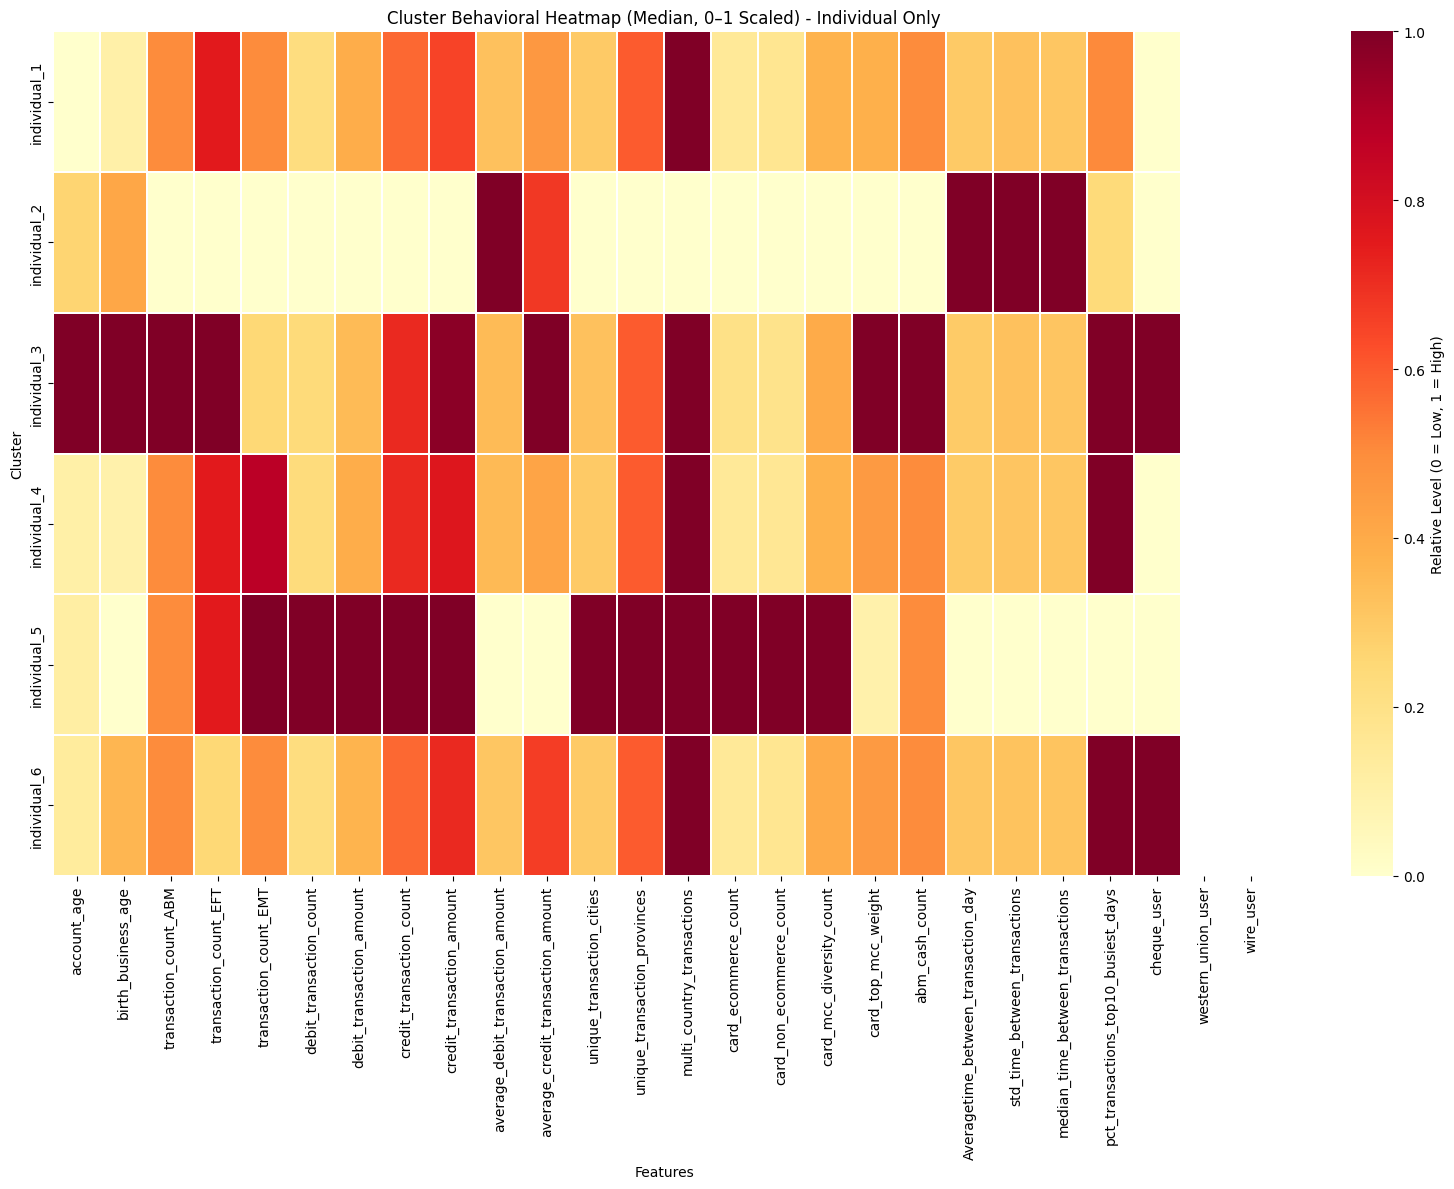

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns.drop("cluster", errors="ignore")

# Cluster medians
cluster_medians = df.groupby("cluster")[num_cols].median()

# Min–max scale per feature (column-wise)
cluster_medians_01 = (
    cluster_medians - cluster_medians.min()
) / (cluster_medians.max() - cluster_medians.min())

plt.figure(figsize=(16, 12))
sns.heatmap(
    cluster_medians_01,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Relative Level (0 = Low, 1 = High)"}
)

plt.title("Cluster Behavioral Heatmap (Median, 0–1 Scaled) - Individual Only")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [97]:
# Categorize features by score ranges for each cluster
print("=" * 80)
print("FEATURE CATEGORIZATION BY CLUSTER (Numerical Heatmap Scores)")

for cluster in sorted(cluster_medians_01.index):
    cluster_scores = cluster_medians_01.loc[cluster]
    
    # High scores: 0.65 to 1.0
    high_features = cluster_scores[(cluster_scores >= 0.65) & (cluster_scores <= 1.0)].sort_values(ascending=False)
    
    # Moderate scores: 0.35 to 0.65
    moderate_features = cluster_scores[(cluster_scores >= 0.35) & (cluster_scores < 0.65)].sort_values(ascending=False)
    
    high_list = list(high_features.index) if len(high_features) > 0 else []
    moderate_list = list(moderate_features.index) if len(moderate_features) > 0 else []
    
    print(f"cluster {cluster}: High: {high_list} Moderate: {moderate_list}")


FEATURE CATEGORIZATION BY CLUSTER (Numerical Heatmap Scores)
cluster individual_1: High: ['multi_country_transactions', 'transaction_count_EFT', 'credit_transaction_amount'] Moderate: ['unique_transaction_provinces', 'credit_transaction_count', 'pct_transactions_top10_busiest_days', 'transaction_count_ABM', 'transaction_count_EMT', 'abm_cash_count', 'average_credit_transaction_amount', 'debit_transaction_amount', 'card_top_mcc_weight', 'card_mcc_diversity_count']
cluster individual_2: High: ['average_debit_transaction_amount', 'Averagetime_between_transaction_day', 'std_time_between_transactions', 'median_time_between_transactions', 'average_credit_transaction_amount'] Moderate: ['birth_business_age']
cluster individual_3: High: ['account_age', 'birth_business_age', 'transaction_count_ABM', 'transaction_count_EFT', 'average_credit_transaction_amount', 'multi_country_transactions', 'card_top_mcc_weight', 'abm_cash_count', 'pct_transactions_top10_busiest_days', 'cheque_user', 'credit_tra

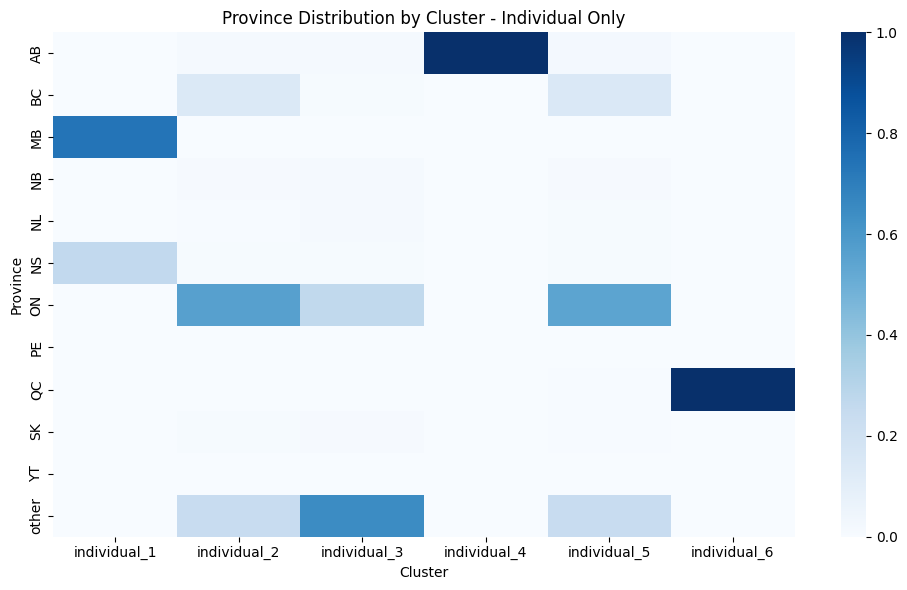

In [98]:
province_dist = pd.crosstab(
    df["province"],
    df["cluster"],
    normalize="columns"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    province_dist,
    cmap="Blues"
)
plt.title("Province Distribution by Cluster - Individual Only")
plt.xlabel("Cluster")
plt.ylabel("Province")
plt.tight_layout()
plt.show()

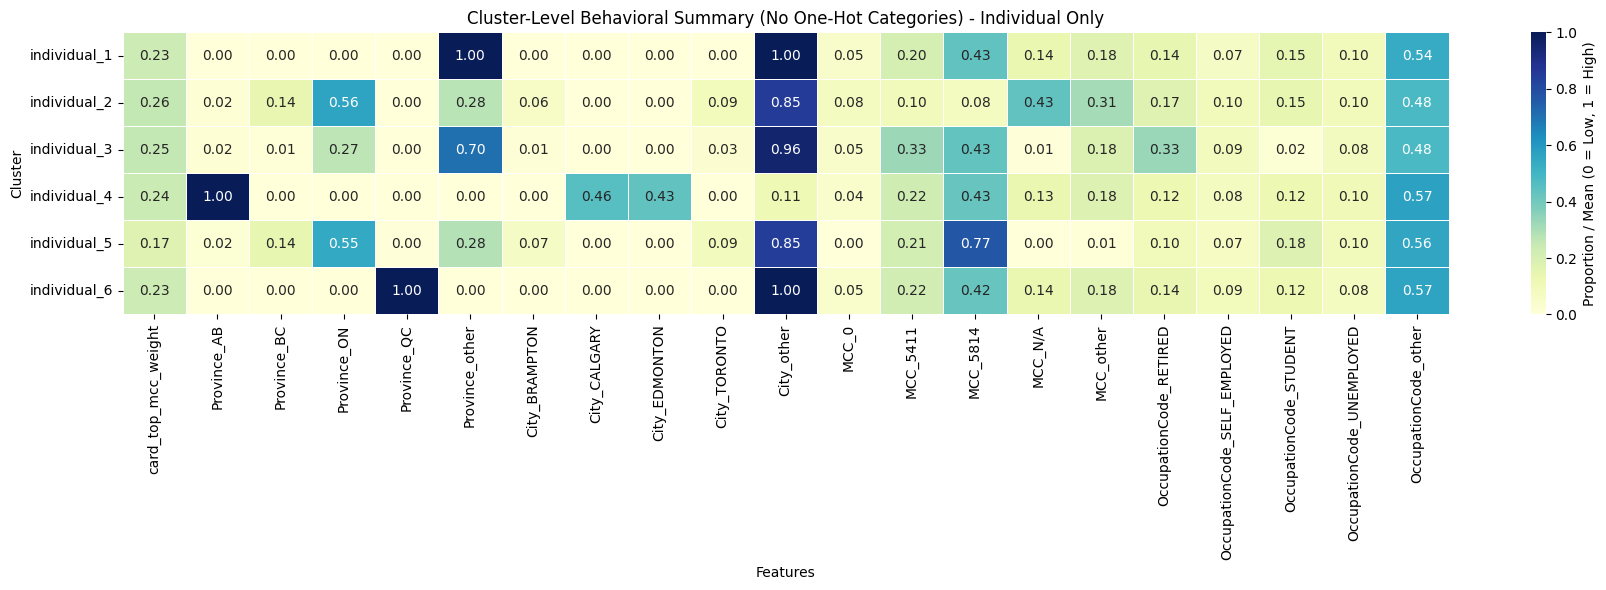

In [99]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Function: categorical proportions
def categorical_cluster_proportions(df, cluster_col, cat_col, top_n=5):
    """
    Rows = clusters
    Columns = top-N categories (+ other)
    Values = proportion within cluster
    """
    # Convert to string if categorical to avoid type errors
    col_series = df[cat_col].astype(str) if df[cat_col].dtype.name == 'category' else df[cat_col]
    
    # Normalize all "other" variations to lowercase "other" first
    # Preserve original case for non-other values
    other_mask = col_series.str.lower() == 'other'
    col_series_normalized = col_series.copy()
    col_series_normalized[other_mask] = 'other'
    
    # Get top_n values from normalized series
    top_vals = col_series_normalized.value_counts().head(top_n).index.tolist()
    
    # Since we've normalized all "other" to lowercase, we can safely collapse to "other"
    collapsed = col_series_normalized.where(col_series_normalized.isin(top_vals), "other")

    return pd.crosstab(
        df[cluster_col],
        collapsed,
        normalize="index"
    )

# Build heatmap dataframe
heatmap_df = pd.DataFrame(
    index=sorted(df["cluster"].unique())
)

# Numeric dominance / indicator-style features
heatmap_df["card_top_mcc_weight"] = (
    df.groupby("cluster")["card_top_mcc_weight"].mean()
)


# Categorical summaries (NO indicators)

# Province (top 5)
prov_prop = categorical_cluster_proportions(df, "cluster", "province", top_n=5)
prov_prop.columns = [f"Province_{c}" for c in prov_prop.columns]
heatmap_df = heatmap_df.join(prov_prop)

# City (top 5)
city_prop = categorical_cluster_proportions(df, "cluster", "city", top_n=5)
city_prop.columns = [f"City_{c}" for c in city_prop.columns]
heatmap_df = heatmap_df.join(city_prop)

# Top MCC (top 5)
mcc_prop = categorical_cluster_proportions(df, "cluster", "card_top_mcc", top_n=5)
mcc_prop.columns = [f"MCC_{c}" for c in mcc_prop.columns]
heatmap_df = heatmap_df.join(mcc_prop)

# Occupation code (top 5)
occupation_code_prop = categorical_cluster_proportions(df, "cluster", "occupation_code", top_n=5)
occupation_code_prop.columns = [f"OccupationCode_{c}" for c in occupation_code_prop.columns]
heatmap_df = heatmap_df.join(occupation_code_prop)

# Plot heatmap 
plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Proportion / Mean (0 = Low, 1 = High)"}
)

plt.title("Cluster-Level Behavioral Summary (No One-Hot Categories) - Individual Only")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [ ]:
# Silhouette + Elbow score from imported cluster_num
import numpy as np
from sklearn.metrics import silhouette_score

# Use the exact matrix used at the top for this notebook
if "X_32" in globals():
    X_eval = np.asarray(X_32, dtype=np.float64)
elif "X9" in globals():
    X_eval = np.asarray(X9, dtype=np.float64)
elif "X" in globals():
    X_eval = np.asarray(X, dtype=np.float64)
else:
    raise ValueError("Expected X_32/X9 (or X) in memory. Run the top clustering cells first.")

# Labels imported from CSV (already aligned earlier in this notebook)
if "m" in globals() and "cluster_num" in m.columns:
    y = m["cluster_num"].astype(int).to_numpy()
elif "df" in globals() and "cluster" in df.columns:
    y = df["cluster"].astype(str).str.extract(r"(\d+)$", expand=False).astype(int).to_numpy()
else:
    raise ValueError("Expected aligned labels in `m['cluster_num']` or `df['cluster']`.")

if X_eval.shape[0] != y.shape[0]:
    raise ValueError(f"Row mismatch: X has {X_eval.shape[0]} rows but labels have {y.shape[0]} rows.")

sil = silhouette_score(X_eval, y)

# Elbow score = within-cluster sum of squares using imported labels
elbow_score = 0.0
for lab in np.unique(y):
    pts = X_eval[y == lab]
    centroid = pts.mean(axis=0)
    elbow_score += ((pts - centroid) ** 2).sum()

print(f"Rows evaluated: {len(y):,}")
print(f"k (from cluster_num): {len(np.unique(y))}")
print(f"Silhouette score: {sil:.6f}")
print(f"Elbow score: {elbow_score:,.2f}")


Rows evaluated: 53,099
k (from cluster_num): 6
Silhouette score: 0.281327
Elbow score: 547,929.81
